## STEP 1 - Grid Loss ML model
`../data/final_model_dataset.csv`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

In [9]:
AGG_DATA = '../data/final_model_dataset.csv'
MODEL_DATA = '../data/model_dataset.csv'
OUTPUT = '../output/'

In [10]:
df = pd.read_csv(AGG_DATA)
df_model = pd.read_csv(MODEL_DATA)
df.head()

,flood_ratio,mean_hag,pct_elevated,mean_age,res_ratio,bldg_density,mean_bldg_value,mean_sqft,areaSqKm_developed,loss_ratio
0,0.3695,3.5997,1.0000,29.6751,0.9665,2.6621,85937.2733,1650.1149,119.1564,0.2739
1,0.1452,3.6441,1.0000,38.7701,0.9619,16.6220,132720.7178,2089.1445,119.1564,0.2450
2,0.0785,3.4353,1.0000,35.1339,0.9430,22.6443,166815.8341,2668.4373,119.1564,0.0609
3,0.2083,3.3161,0.9967,26.1266,0.9787,23.5857,135171.5674,1925.3932,119.1564,0.1933
4,0.1010,3.6506,0.9997,28.7604,0.9759,24.6003,131343.1496,2146.0928,119.1564,0.0563


### 1. Model Preparation

In [4]:
# ── Feature matrix ────
y = df['loss_ratio'].values
X = df.drop(columns=['loss_ratio']).values

FEATURES = df.drop(columns=['loss_ratio']).columns.tolist()
print(f'Features: {FEATURES}')
print(f'Model dataset: {X.shape[0]} rows × {X.shape[1]} features')


Features: ['flood_ratio', 'mean_hag', 'pct_elevated', 'mean_age', 'res_ratio', 'bldg_density', 'mean_bldg_value', 'mean_sqft', 'areaSqKm_developed']
Model dataset: 220 rows × 9 features


### 2. Model Training & Cross-Validation

In [5]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression':  Ridge(alpha=1.0),
    'Random Forest':     RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=3,
                                                    learning_rate=0.05, random_state=42),
}

cv_results = {}
for name, model in models.items():
    r2   = cross_val_score(model, X, y, cv=kf, scoring='r2')
    rmse = cross_val_score(model, X, y, cv=kf, scoring='neg_root_mean_squared_error')
    cv_results[name] = {
        'R² Mean':  r2.mean(),
        'R² Std':   r2.std(),
        'RMSE Mean': -rmse.mean(),
        'RMSE Std':  rmse.std(),
    }

cv_df = pd.DataFrame(cv_results).T.round(4)
print('=== 5-Fold Cross-Validation Results ===')
cv_df

=== 5-Fold Cross-Validation Results ===


,R² Mean,R² Std,RMSE Mean,RMSE Std
Linear Regression,0.0435,0.0647,0.1348,0.0067
Ridge Regression,0.0649,0.0400,0.1334,0.0071
Random Forest,0.2060,0.1402,0.1222,0.0102
Gradient Boosting,-0.0827,0.2848,0.1416,0.0172


### 3. Random Forest: Model Interpretation
Random Forest is selected as the primary model for uninsured loss estimation  
due to its ability to capture non-linear interactions between building characteristics  
and flood exposure, while remaining robust to the limited sample size (n=220).

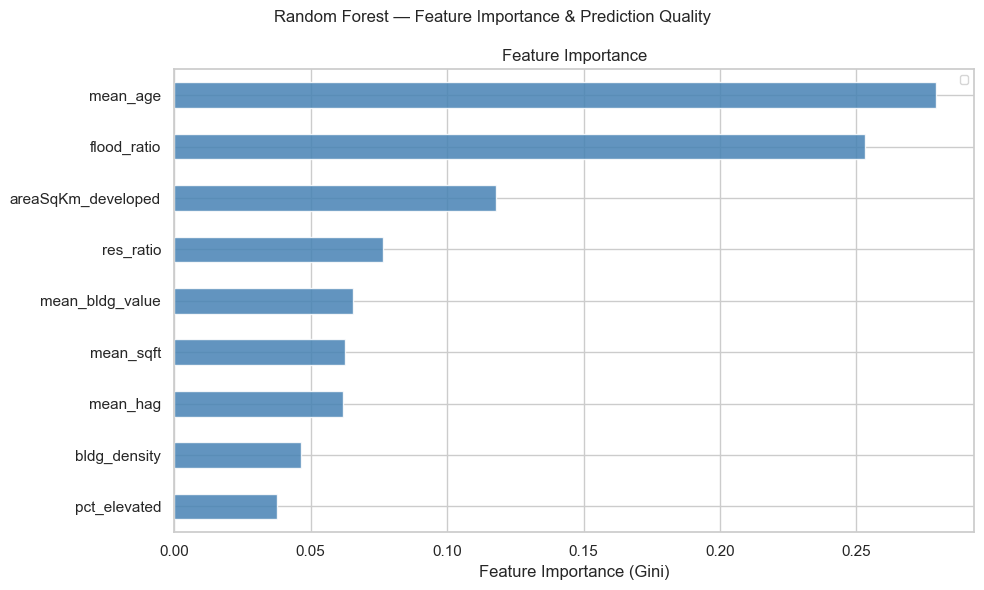

In [6]:
# ── Fit RF on full dataset ──────
rf_final = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
rf_final.fit(X, y)

y_pred = rf_final.predict(X)

# Feature importance
fi = pd.Series(rf_final.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
fig.suptitle('Random Forest — Feature Importance & Prediction Quality', fontsize=12)

# Feature importance bar
fi.plot(kind='barh', ax=ax, color='steelblue', alpha=0.85)
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Feature Importance')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT + 'feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 2 — Uninsured Loss Estimation

### Methodology

Following the `loss_ratio` prediction from Random Forest model. We calculate: 


$$\text{Estimated Total Loss} = \hat{\text{loss\_ratio}} \times \text{total\_bldg\_val}$$

$$\text{Uninsured Gap} = \text{Estimated Total Loss} - \text{NFIP Actual Payout}$$

> `total_bldg_val` represents the insured building value.  
> captured in FEMA claims. `total_bldg_value` (NC Buildings GDB) represents all structures.  
> The uninsured gap is therefore a **conservative lower bound** — true uninsured losses are likely higher.

In [11]:
# ── Apply model to all grid cells ──────
df_model['predicted_loss_ratio'] = rf_final.predict(X)
df_model['estimated_total_loss'] = df_model['predicted_loss_ratio'] * df_model['total_bldg_val']
df_model['uninsured_gap']        = (df_model['estimated_total_loss'] - df_model['total_paid']).clip(lower=0)
df_model['uninsured_pct']        = (
    df_model['uninsured_gap'] / df_model['estimated_total_loss'].replace(0, np.nan) * 100
).fillna(0)

print('=== Grid-level uninsured gap (sample) ===')
cols_show = ['grid_id','event_name','year','county','total_paid',
             'estimated_total_loss','uninsured_gap','uninsured_pct']
df_model[cols_show].sort_values('uninsured_gap', ascending=False).head(10).round(0)

=== Grid-level uninsured gap (sample) ===


,grid_id,event_name,year,county,total_paid,estimated_total_loss,uninsured_gap,uninsured_pct
209,35.4_-76.6,Hurricane Bonnie,1998,Beaufort,2177295.0000,123727683.0000,121550388.0000,98.0000
93,35.2_-77.6,Hurricane Floyd,1999,Lenoir,7037412.0000,108251267.0000,101213854.0000,93.0000
171,35.4_-77.1,Hurricane Fran,1996,Beaufort,1197777.0000,22638699.0000,21440922.0000,95.0000
27,35.3_-78.0,Hurricane Florence,2018,Wayne,2076274.0000,6289433.0000,4213159.0000,67.0000
124,35.8_-77.8,Hurricane Floyd,1999,Edgecombe,847070.0000,4018715.0000,3171645.0000,79.0000
4,34.5_-79.1,Hurricane Florence,2018,Robeson,1562921.0000,4625271.0000,3062350.0000,66.0000
137,35.4_-76.6,Hurricane Irene,2011,Beaufort,5834941.0000,7463901.0000,1628960.0000,22.0000
84,35.9_-77.8,Hurricane Matthew,2016,Edgecombe,2827718.0000,4340932.0000,1513213.0000,35.0000
40,35.5_-77.1,Hurricane Florence,2018,Beaufort,129386.0000,1391204.0000,1261819.0000,91.0000
60,35.3_-78.0,Hurricane Matthew,2016,Wayne,15430320.0000,16632287.0000,1201967.0000,7.0000


In [12]:
# ── Aggregate by storm ──────
storm_gap = (
    df_model.groupby(['event_name', 'year'])
    .agg(
        nfip_paid_M    = ('total_paid',          lambda x: x.sum() / 1e6),
        est_total_M    = ('estimated_total_loss', lambda x: x.sum() / 1e6),
        uninsured_M    = ('uninsured_gap',        lambda x: x.sum() / 1e6),
        n_grids        = ('grid_id',              'count'),
    )
    .assign(uninsured_pct = lambda x: (x['uninsured_M'] / x['est_total_M'] * 100).round(1))
    .round(2)
    .sort_values('year')
)

print('=== Uninsured Loss by Storm ===')
storm_gap

=== Uninsured Loss by Storm ===


,,nfip_paid_M,est_total_M,uninsured_M,n_grids,uninsured_pct
event_name,year,,,,,
Hurricane Fran,1996,13.4800,33.1000,21.5800,30,65.2000
Hurricane Bonnie,1998,7.5200,128.7900,121.9500,19,94.7000
Hurricane Floyd,1999,34.9700,136.1800,105.3000,43,77.3000
Hurricane Isabel,2003,4.1800,5.8500,1.7600,20,30.0000
Hurricane Irene,2011,30.5600,27.5400,2.6000,23,9.4000
Hurricane Matthew,2016,79.5400,70.6400,4.9500,43,7.0000
Hurricane Florence,2018,58.9800,64.3800,11.5300,42,17.9000


In [13]:
# ── Aggregate by county ─────
county_gap = (
    df_model.groupby('county')
    .agg(
        nfip_paid_M  = ('total_paid',          lambda x: x.sum() / 1e6),
        est_total_M  = ('estimated_total_loss', lambda x: x.sum() / 1e6),
        uninsured_M  = ('uninsured_gap',        lambda x: x.sum() / 1e6),
        n_obs        = ('grid_id',              'count'),
    )
    .assign(uninsured_pct = lambda x: (x['uninsured_M'] / x['est_total_M'] * 100).round(1))
    .round(2)
    .sort_values('uninsured_pct', ascending=False)
)

print('=== Uninsured Loss by County (across all storms) ===')
county_gap

=== Uninsured Loss by County (across all storms) ===


,nfip_paid_M,est_total_M,uninsured_M,n_obs,uninsured_pct
county,,,,,
Lenoir,39.5000,135.1700,102.5600,26,75.9000
Beaufort,84.6600,222.2300,151.0500,107,68.0000
Edgecombe,23.8000,25.5400,5.6800,33,22.2000
Wayne,35.9700,39.6000,5.9400,25,15.0000
Robeson,45.2900,43.9500,4.4400,29,10.1000


## Step 8 — Visualization of Uninsured Loss

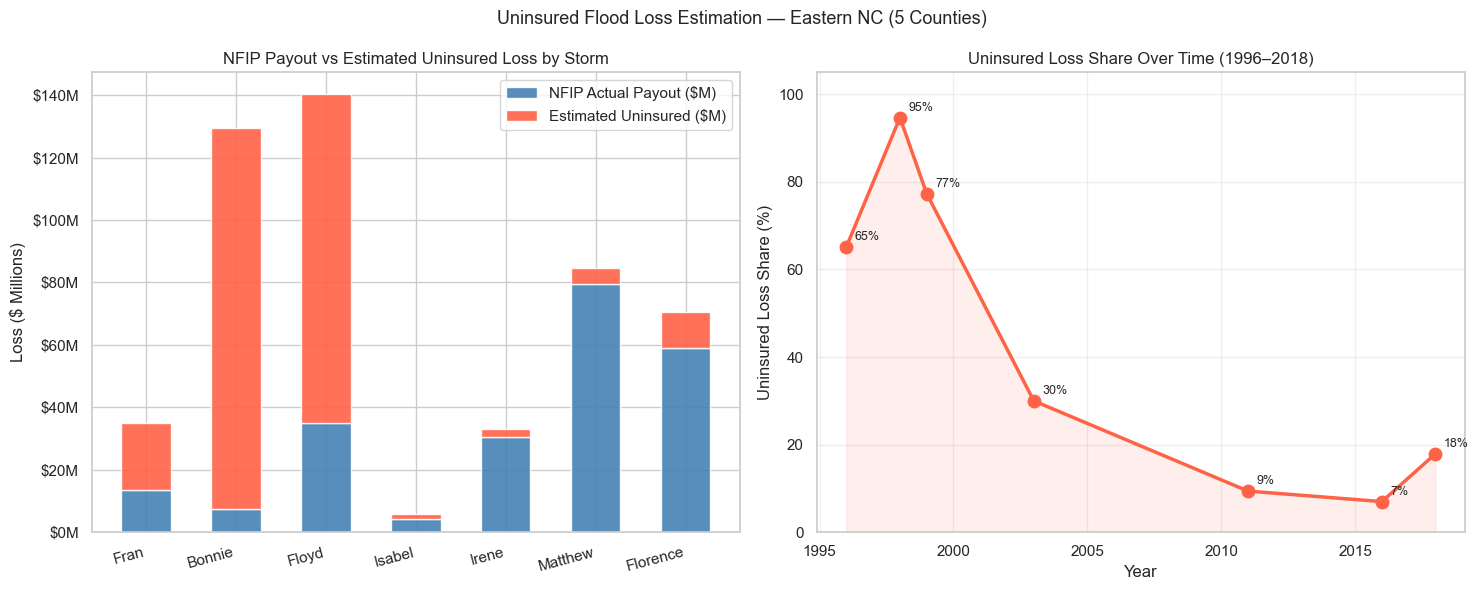

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Uninsured Flood Loss Estimation — Eastern NC (5 Counties)', fontsize=13)

sg = storm_gap.reset_index().sort_values('year')
short_names = sg['event_name'].str.replace('Hurricane ', '')
x = np.arange(len(sg))

# ── Stacked bar: NFIP paid vs uninsured ──────
axes[0].bar(x, sg['nfip_paid_M'],  0.55, label='NFIP Actual Payout ($M)',    color='steelblue', alpha=0.9)
axes[0].bar(x, sg['uninsured_M'],  0.55, label='Estimated Uninsured ($M)',   color='tomato',    alpha=0.9,
            bottom=sg['nfip_paid_M'])
axes[0].set_xticks(x)
axes[0].set_xticklabels(short_names, rotation=15, ha='right')
axes[0].set_ylabel('Loss ($ Millions)')
axes[0].set_title('NFIP Payout vs Estimated Uninsured Loss by Storm')
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.0f}M'))

# ── Uninsured % over time ─────
axes[1].plot(sg['year'], sg['uninsured_pct'], marker='o', color='tomato',
             linewidth=2.5, markersize=9, zorder=3)
for _, row in sg.iterrows():
    axes[1].annotate(
        f"{row['uninsured_pct']:.0f}%",
        (row['year'], row['uninsured_pct']),
        textcoords='offset points', xytext=(6, 5), fontsize=9
    )
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Uninsured Loss Share (%)')
axes[1].set_title('Uninsured Loss Share Over Time (1996–2018)')
axes[1].set_ylim(0, 105)
axes[1].grid(True, alpha=0.3)
axes[1].fill_between(sg['year'], sg['uninsured_pct'], alpha=0.1, color='tomato')

plt.tight_layout()
plt.savefig(OUTPUT + 'uninsured_loss_by_storm.png', dpi=300, bbox_inches='tight')
plt.show()

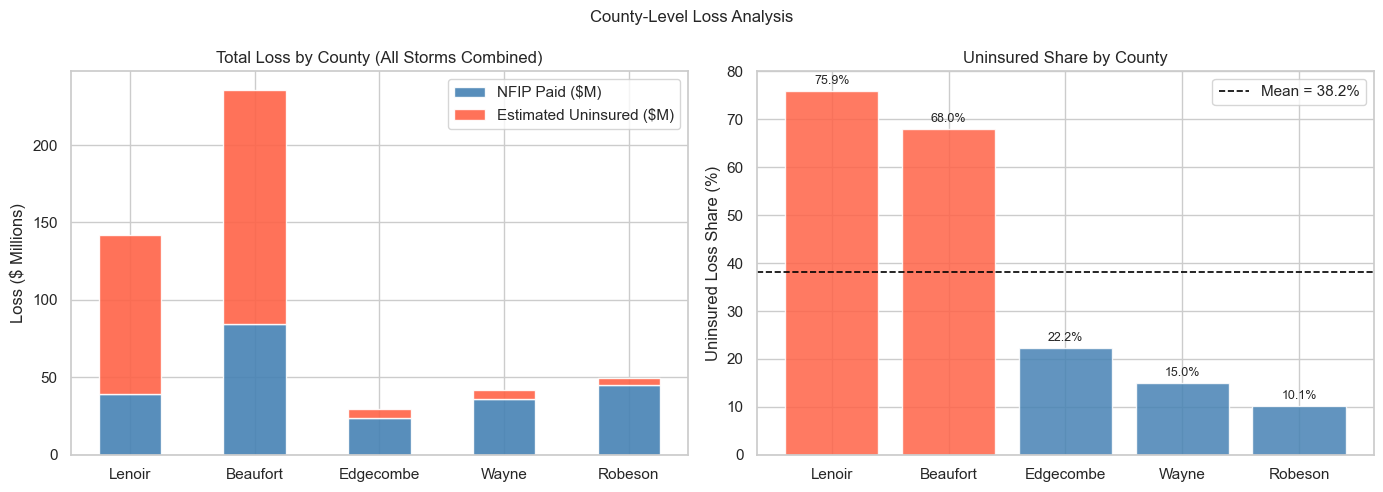

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('County-Level Loss Analysis', fontsize=12)

cg = county_gap.reset_index()

# ── Stacked bar by county ─────
x = np.arange(len(cg))
axes[0].bar(x, cg['nfip_paid_M'],  0.5, label='NFIP Paid ($M)',           color='steelblue', alpha=0.9)
axes[0].bar(x, cg['uninsured_M'],  0.5, label='Estimated Uninsured ($M)', color='tomato',    alpha=0.9,
            bottom=cg['nfip_paid_M'])
axes[0].set_xticks(x)
axes[0].set_xticklabels(cg['county'])
axes[0].set_ylabel('Loss ($ Millions)')
axes[0].set_title('Total Loss by County (All Storms Combined)')
axes[0].legend()

# ── Uninsured % by county ─────
colors = ['tomato' if v > 30 else 'steelblue' for v in cg['uninsured_pct']]
axes[1].bar(cg['county'], cg['uninsured_pct'], color=colors, alpha=0.85)
axes[1].axhline(cg['uninsured_pct'].mean(), color='black', linestyle='--',
                linewidth=1.2, label=f"Mean = {cg['uninsured_pct'].mean():.1f}%")
axes[1].set_ylabel('Uninsured Loss Share (%)')
axes[1].set_title('Uninsured Share by County')
axes[1].set_ylim(0, 80)
axes[1].legend()
for i, (_, row) in enumerate(cg.iterrows()):
    axes[1].text(i, row['uninsured_pct'] + 1.5, f"{row['uninsured_pct']:.1f}%",
                 ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT + 'uninsured_loss_by_county.png', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
print('=== Predicted vs Actual loss_ratio by storm ===')
print(df_model.groupby('event_name')[['loss_ratio','predicted_loss_ratio']].mean().round(4))

print()
print('=== Residuals distribution ===')
df_model['residual'] = df_model['loss_ratio'] - df_model['predicted_loss_ratio']
print(df_model['residual'].describe().round(4))

print()
print('=== Is the model just predicting the mean? ===')
print(f'Std of actual predictions : {df_model["predicted_loss_ratio"].std():.4f}')
print(f'Std of actual loss_ratio  : {df_model["loss_ratio"].std():.4f}')
print(f'Mean of predictions       : {df_model["predicted_loss_ratio"].mean():.4f}')
print(f'Mean of actual            : {df_model["loss_ratio"].mean():.4f}')

=== Predicted vs Actual loss_ratio by storm ===
                    loss_ratio  predicted_loss_ratio
event_name                                          
Hurricane Bonnie        0.0766                0.0955
Hurricane Florence      0.1326                0.1492
Hurricane Floyd         0.2394                0.2215
Hurricane Fran          0.1390                0.1272
Hurricane Irene         0.1122                0.1079
Hurricane Isabel        0.0683                0.0915
Hurricane Matthew       0.1946                0.1921

=== Residuals distribution ===
count   220.0000
mean     -0.0009
std       0.0789
min      -0.2258
25%      -0.0394
50%      -0.0101
75%       0.0374
max       0.2625
Name: residual, dtype: float64

=== Is the model just predicting the mean? ===
Std of actual predictions : 0.0881
Std of actual loss_ratio  : 0.1391
Mean of predictions       : 0.1545
Mean of actual            : 0.1536
